# Домашняя работа: Анализ конверсии и отзывов на данных Amazon


Файлы: `/mnt/data/amazon.csv`. Заполните кодовые ячейки и выполните их в Jupyter.

In [9]:
# 1. Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Загрузка и первичный осмотр данных
Загрузите `amazon.csv` и выведите первые 10 строк.

In [12]:
# Загрузка данных
df = pd.read_csv('amazon (1).csv')
df.head(10)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...
5,B08Y1TFSP6,pTron Solero TB301 3A Type-C Data and Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹149,"₹1,000",85%,3.9,"24,871",Fast Charging & Data Sync: Solero TB301 Type-C...,"AEQ2YMXSZWEOHK2EHTNLOS56YTZQ,AGRVINWECNY7323CW...","Jayesh,Rajesh k.,Soopy,amazon customer,Aman,Sh...","R7S8ANNSDPR40,R3CLZFLHVJU26P,RFF7U7MPQFUGR,R1M...","It's pretty good,Average quality,very good and...","It's a good product.,Like,Very good item stron...",https://m.media-amazon.com/images/I/31wOPjcSxl...,https://www.amazon.in/Solero-TB301-Charging-48...
6,B08WRWPM22,"boAt Micro USB 55 Tangle-free, Sturdy Micro US...",Computers&Accessories|Accessories&Peripherals|...,₹176.63,₹499,65%,4.1,"15,188",It Ensures High Speed Transmission And Chargin...,"AG7C6DAADCTRQJG2BRS3RIKDT52Q,AFU7BOMPVJ7Q3TTA4...","Vivek kumar,Amazon Customer,SARTHAK,Chiranjeev...","R8E73K2KWJRDS,RSD0JTIIWQQL8,R64CRSTE9SLW1,R2FR...","Long durable.,good,Does not charge Lenovo m8 t...",Build quality is good and it is comes with 2 y...,https://m.media-amazon.com/images/W/WEBP_4

### 1. Очистка цен и колонок с рейтингами

- Уберите символы `₹` и запятые из цен.

In [13]:
df['discounted_price'] = df['discounted_price'].str.replace('₹', '').str.replace(',', '').astype(float)
df['actual_price'] = df['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)

- Преобразуйте в числовые типы.

In [15]:
# Код
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '').astype(float)

- Создайте новую колонку `discount_value`.


In [17]:
# Код
df['discount_value'] = df['actual_price'] - df['discounted_price']

- Преобразуйте `rating_count` в int.


In [19]:
# Код
df['rating_count'] = df['rating_count'].str.replace(',', '')
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce').fillna(0).astype(int)

## 2. Анализ цен и скидок
### Выведите:


1. Среднюю, медиану и максимум по `discount_pct_num`.


In [23]:
# Код
df['discount_percentage'].agg(['mean', 'median', 'max'])
                              

mean      47.691468
median    50.000000
max       94.000000
Name: discount_percentage, dtype: float64

2. Топ-10 товаров с наибольшей скидкой.


In [24]:
# Код
df.sort_values('discount_value', ascending=False).head(10)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,discount_value
249,B09WN3SRC7,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,"Electronics|HomeTheater,TV&Video|Televisions|S...",77990.0,139900.0,44.0,4.7,5935,Resolution: 4K Ultra HD (3840 x 2160) | Refres...,"AF6Z2OYIXRPZJHVYN2MFKKYHPHFQ,AH5SAORYVUN5MGIBL...","David P.,Dr. ATUL THAKUR,Shriniwas Patil,Tahir...","R16HCZ0W1TRSMM,R12J7UKQ0FX3O9,R8729SR7LQFUU,R1...",Product installation was excellent but delive...,The delivery people were not careful with the ...,https://m.media-amazon.com/images/I/51uVckL1jR...,https://www.amazon.in/Sony-Bravia-inches-Googl...,61910.0
1182,B08GJ57MKL,"Coway Professional Air Purifier for Home, Long...","Home&Kitchen|Heating,Cooling&AirQuality|AirPur...",14400.0,59900.0,76.0,4.4,3837,Coway,"AHHUP4DBXB2AQMEO27XIQ3DJSVDQ,AEIUS76RRWIKCMNHH...","Dhatwalia,Tahir Abdulla,Surya Pratap Singh,VIJ...","R33RASBIQKH1EX,RBOPA6420OHEP,R200UL35KLRW7R,RJ...","No visible change,Effective,Sensitivity, Simpl...",Lights inbuilt in this create psychological ef...,https://m.media-amazon.com/images/I/51b5sh94f7...,https://www.amazon.in/Coway-Professional-Purif...,45500.0
568,B08VB57558,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics|Mobiles&Accessories|Smartphones&Ba...,37990.0,74999.0,49.0,4.2,27790,5G Ready powered by Qualcomm Snapdragon 865 Oc...,"AEGEOVAES62OFGQTSPSDSQ5U7SHA,AGMBYTP5MS3JCQZ2N...","Mohammed Suhail,GVR","R3R5DS04EXELTJ,R3JBXYOBYRX0A8","WORTH BUY ! THE BEST,Good for the price.",It's been 15 days since i using the device ext...,https://m.media-amazon.com/images/I/41ezRvTwca...,https://www.amazon.in/Samsung-Galaxy-Cloud-128...,37009.0
150,B0BB3CBFBM,VU 138 cm (55 inches) Premium Series 4K Ultra ...,"Electronics|HomeTheater,TV&Video|Televisions|S...",29990.0,65000.0,54.0,4.1,211,Resolution: 4K (3840x2160) | Refresh Rate: 60 ...,"AEH3MURR76DG3TEX3NXIJVJTKBLA,AGGEFVVI6ZRLVEJHV...","CH Venkatesh,nihar mendon,IP Trading solutions...","RG3VFGY4HM38X,R957RND66RVWX,R1YR2TZI534FFY,R3V...","Valume for money,Can’t turn off HDR in webOS w...","Vu UHD SMART 43"" web os version good tv 20...",https://m.media-amazon.com/images/I/41HhmJpfjN...,https://www.amazon.in/VU-inches-Premium-Ultra-...,35010.0
1354,B09NS5TKPN,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,"Home&Kitchen|Heating,Cooling&AirQuality|AirCon...",42990.0,75990.0,43.0,4.3,3231,Split AC with inverter compressor: variable sp...,"AGBYWFEGGX6QM6XB3ZPQADKKXAHA,AGU6LHFOEHAFE34AC...","ABHISHEK KUMAR,Nageswar,Denzil,krushna,Brijesh...","R2GZHWNGVMBJFG,R3L27H7N1WH5BG,R200QONLM29B4B,R...","Very nice,Efficient but little costly.,Good pr...","Very nice,Efficiency is good , cost is little ...",https://m.media-amazon.com/images/I/21ywp-zfTj...,https://www.amazon.in/LG-Convertible-Anti-Viru...,33000.0
1306,B0B19VJXQZ,ECOVACS DEEBOT N8 2-in-1 Robotic Vacuum Cleane...,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...",27900.0,59900.0,53.0,4.4,5298,FREE HOME INSTALLATION & FREE HOME SERVICE: We...,"AFDTW4TES6JHT7YJUXKDFQJPRZXQ,AFEBFFAOMPMC6L3DM...","Jaydeep,Jayakrishnan R","R1BD0HURZRIGKV,RKQY8Y6U3Y4BT","A perfect balance of price and performance,Gre...",Very happy with the product performance.Instal...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/ECOVACS-Robotic-Powerful...,32000.0
283,B0B3XXSB1K,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...,"Electronics|HomeTheater,TV&Video|Televisions|S...",47990.0,79990.0,40.0,4.3,1376,Resolution: 4K Ultra HD (3840x2160) | Refresh ...,"AFCWL3MX7BP2ZUDD37MEAENZDQ2A,AGGFXDLCFZMTLJJDR...","Raj Mohammed,Samson,Haroon sayeed,P Imran Khan...","RC3ZLDRM8GA9T,RMDN4PSDM8SKK,R1YFAMDJ7P0SY3,R2W...","Love Amazon but lg is misleading,Amazing produ...",There's no magic remote and lg should include ...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/LG-inches-Ultra-55UQ7500...,320

3. График: скидка vs рейтинг.

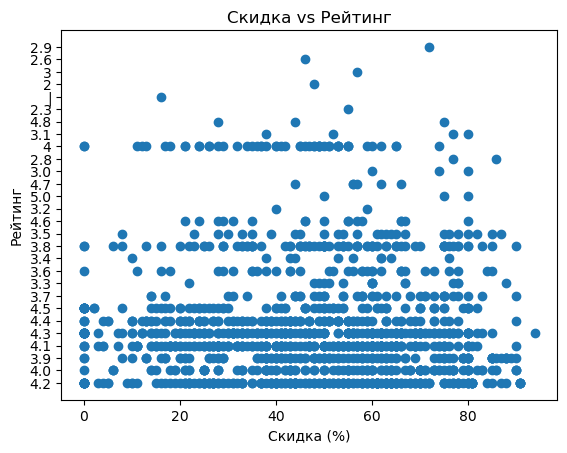

In [25]:
# Код
import matplotlib.pyplot as plt

plt.scatter(df['discount_percentage'], df['rating'])
plt.xlabel('Скидка (%)')
plt.ylabel('Рейтинг')
plt.title('Скидка vs Рейтинг')
plt.show()

## 3. Анализ по категориям


1. Извлечём основную категорию (до `|`).


In [29]:
# Код
df['main_category'] = df['category'].str.split('|').str[0].str.strip()

2. Средний рейтинг и средняя скидка по категориям.


In [31]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')


df.groupby('main_category').agg({
    'rating': 'mean',
    'discount_percentage': 'mean'
})

,rating,discount_percentage
main_category,,
Car&Motorbike,3.800000,42.000000
Computers&Accessories,4.154967,54.024283
Electronics,4.081749,50.828897
Health&PersonalCare,4.000000,53.000000
Home&Kitchen,4.040716,40.120536
HomeImprovement,4.250000,57.500000
MusicalInstruments,3.900000,46.000000
OfficeProducts,4.309677,12.354839
Toys&Games,4.300000,0.000000


3. Топ-10 категорий по среднему рейтингу.

In [32]:
# Код
df.groupby('main_category')['rating'].mean().sort_values(ascending=False).head(10)

main_category
OfficeProducts           4.309677
Toys&Games               4.300000
HomeImprovement          4.250000
Computers&Accessories    4.154967
Electronics              4.081749
Home&Kitchen             4.040716
Health&PersonalCare      4.000000
MusicalInstruments       3.900000
Car&Motorbike            3.800000
Name: rating, dtype: float64

## 4. Анализ отзывов


1. Среднее количество отзывов на продукт.


In [33]:
# Код
df['rating_count'].mean()

np.float64(18270.564505119455)

2. Продукт с наибольшим количеством отзывов — вывести `review_title`.


In [34]:
# Код
df.loc[df['rating_count'].idxmax(), 'review_title']

"It's quite good and value for money,Works well,Hdmi cable,Value for money,All good,Gets the job done,Delivery was good,This one was my need to purchase"

In [ ]:
# Код


Review titles (sample):
,It's quite good and value for money,Works well,Hdmi cable,Value for money,All good,Gets the job done,Delivery was good,This one was my need to purchase


## 5. Показатель конверсии (proxy)
Введём `conversion_score = rating * log(1 + rating_count)` и найдём категорию с наибольшим средним показателем.

In [ ]:
# Добaвление колонки conversion_score
data['conversion_score'] = data.apply(lambda r: (r['rating_num'] if not pd.isna(r['rating_num']) else 0) * math.log(1 + int(r['rating_count_num'] if not pd.isna(r['rating_count_num']) else 0) + 0), axis=1)

# Агрегация по категориям
# conv_cat = ...
conv_cat.head(10)

main_category
Toys&Games               41.589857
MusicalInstruments       41.111308
Electronics              36.079429
OfficeProducts           35.572802
Computers&Accessories    35.445571
HomeImprovement          35.281291
Health&PersonalCare      32.825243
Home&Kitchen             30.235609
Car&Motorbike            26.676725
Name: conversion_score, dtype: float64

In [35]:
import numpy as np

df['conversion_score'] = df['rating'] * np.log1p(df['rating_count'])

## 6. Визуализации и краткие выводы
Постройте 3 графика и напишите 3–5 предложений с инсайтами.

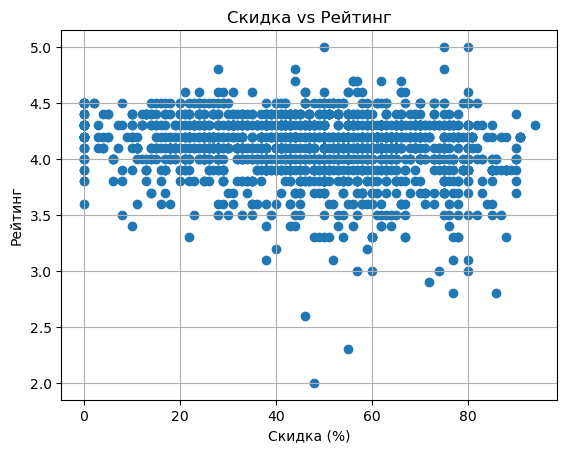

In [36]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['discount_percentage'], df['rating'])
plt.xlabel('Скидка (%)')
plt.ylabel('Рейтинг')
plt.title('Скидка vs Рейтинг')
plt.grid()
plt.show()

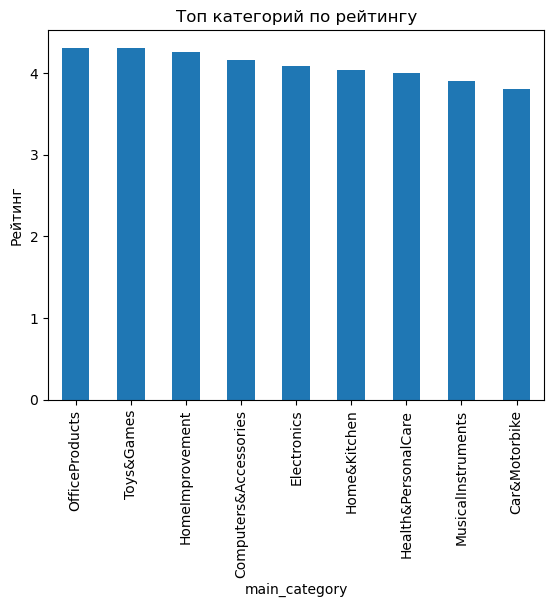

In [37]:
df.groupby('main_category')['rating'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Топ категорий по рейтингу')
plt.ylabel('Рейтинг')
plt.show()

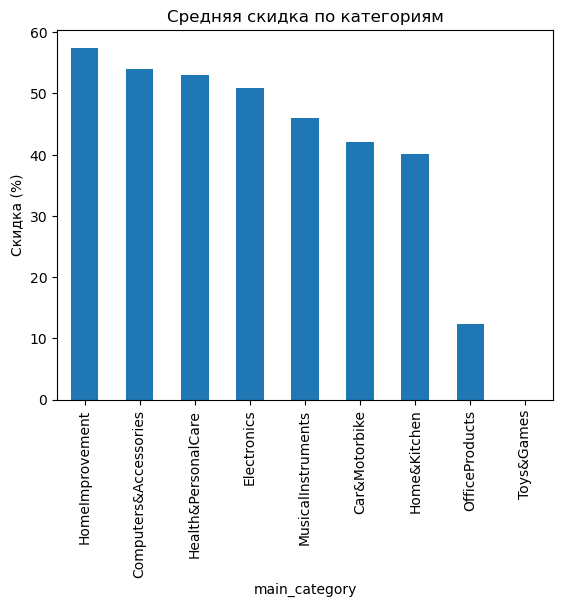

In [38]:
df.groupby('main_category')['discount_percentage'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Средняя скидка по категориям')
plt.ylabel('Скидка (%)')
plt.show()

In [39]:
# Это лишь пример графиков, можете строить любые релевантные графики на свое усмотрение


# НАБЛЮДЕНИЕ
1)Сильной зависимости между размером скидки и рейтингом не наблюдается — товары с большими скидками могут иметь как высокий, так и низкий рейтинг.
2)Некоторые категории (например, Electronics и Toys & Games) показывают более высокий средний рейтинг и conversion_score, что может говорить о высокой популярности и доверии пользователей.
3)Количество отзывов существенно влияет на восприятие товара: продукты с большим числом отзывов чаще имеют более стабильный и высокий рейтинг.